---
# **E-Commerce Revenue Optimisation & Business Performance Analysis**
---

## **Business Analytics & Exploratory Data Analysis Project**

### **Bhumika Mittal**

---

# **PROJECT OVERVIEW**

The e-commerce sector generates large volumes of transactional data related to customer purchases, product pricing, order quantities, and geographic markets. However, businesses often fail to fully utilize this data for improving revenue performance and strategic decision-making.

This project analyses an online retail transactional dataset to identify key revenue drivers, evaluate product performance, analyse customer purchasing behaviour, and examine geographic sales patterns.

The analysis aims to generate insights that support **revenue optimisation** and **data-driven business decision-making** in e-commerce environments.

---

# **PROJECT OBJECTIVES**

The objectives of this project are:

- To analyse **revenue trends** in the e-commerce dataset.
- To identify **top revenue-generating products**.
- To evaluate **country-wise sales distribution**.
- To analyse **customer contribution to revenue**.
- To derive insights that support **revenue optimisation strategies**.

---

# **TOOLS & TECHNOLOGIES**

- **Python**
- **Pandas**
- **NumPy**
- **Matplotlib**
- **Seaborn**
- **Google Colab**

---

# **NOTEBOOK WORKFLOW**

1. **Import Libraries**
2. **Load Dataset**
3. **Dataset Overview**
4. **Dataset Summary**
5. **Data Cleaning & Preprocessing**
6. **Feature Engineering (Revenue Calculation)**
7. **Revenue Distribution Analysis**
8. **Monthly Revenue Trend Analysis**
9. **Top Revenue Generating Products**
10. **Top Products by Quantity Sold**
11. **Country-wise Revenue Analysis**
12. **Customer Contribution Analysis**
13. **Average Order Value (AOV) Analysis**
14. **Revenue Concentration Analysis (Pareto Analysis)**
15. **Key Business Insights**
16. **Revenue Optimisation Recommendations**
17. **Conclusion**

---

# **DATASET SOURCE**

**Online Retail E-Commerce Dataset**

**Source (Kaggle):** https://www.kaggle.com/datasets/carrie1/ecommerce-data

---

# **1. IMPORTING LIBRARIES**

In [ ]:
# IMPORTING LIBRARIES FOR DATA ANALYSIS & VISUALIZATION
import pandas as pd      # for data manipulation
import numpy as np       # for numerical operations

import matplotlib.pyplot as plt   # for plotting charts
import seaborn as sns             # for advanced visualizations

# SETTING CHART STYLE
sns.set(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


---

# **2. LOADING DATASET**

In [ ]:
# LOADING THE E-COMMERCE DATASET
df = pd.read_csv("OnlineRetail_Ecommerce_Dataset.csv", encoding="ISO-8859-1")

# DISPLAYING FIRST 5 ROWS
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
# **3. DATASET OVERVIEW**

In [ ]:
# CHECKING DATASET DIMENSIONS
df.shape

(541909, 8)

In [ ]:
# DISPLAYING COLUMN NAMES
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
# CHECKING DATA TYPES & MISSING VALUES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


---

### **DATASET OVERVIEW – INSIGHTS**

---

**Key Observations:**

- The dataset contains **541,909 transaction records and 8 variables**, indicating a large retail dataset suitable for business analytics.
- Each record represents a **product purchased within an invoice transaction**.
- Important variables such as **Quantity, UnitPrice, CustomerID, and Country** enable analysis of revenue generation, customer behaviour, and geographic sales patterns.
- The dataset includes transactions from **38 countries**, allowing international market analysis.

---

# **4. DATASET SUMMARY**

In [ ]:
# BASIC DATASET SUMMARY

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Unique customers:", df['CustomerID'].nunique())
print("Unique products:", df['Description'].nunique())
print("Number of countries:", df['Country'].nunique())

Number of rows: 541909
Number of columns: 8
Unique customers: 4372
Unique products: 4223
Number of countries: 38


---

### **DATASET SUMMARY – INSIGHTS**

---

**Key Observations:**

- The dataset includes **4,372 unique customers**, indicating a broad and diverse customer base.
- A total of **4,223 unique products** are recorded, reflecting high product variety within the retail catalogue.
- Transactions originate from **38 countries**, showing the international presence of the business.
- The large number of customers and products allows meaningful analysis of **purchasing behaviour and key revenue drivers**.

---

# **5. DATA CLEANING**

In [ ]:
# REMOVING CANCELLED ORDERS (INVOICE STARTING WITH 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
# REMOVING NEGATIVE QUANTITIES
df = df[df['Quantity'] > 0]

In [ ]:
# REMOVING MISSING CUSTOMER IDS
df = df.dropna(subset=['CustomerID'])

In [ ]:
# CONVERTING DATA COLUMN TO DATETIME
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

---

### **DATA CLEANING – INSIGHTS**

---

**Key Steps Performed:**

- **Cancelled invoices** were removed to ensure that only completed transactions are included in the analysis.
- Records with **negative quantities** were filtered out to eliminate product returns and invalid entries.
- Rows with **missing CustomerID values** were removed to enable accurate customer-level analysis.
- The **InvoiceDate column was converted to datetime format** to support time-based analysis such as monthly revenue trends.

---

# **6. FEATURE ENGINEERING**

In [ ]:
# CREATING REVENUE COLUMN
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---

### **REVENUE VARIABLE**

---

**Key Observation:**

- A new variable **Revenue** was created by multiplying **Quantity × UnitPrice**.
- This variable represents the **total revenue generated per transaction**.
- The **Revenue column** will be used as the primary metric for analysing sales performance throughout the project.

---

# **7. REVENUE DISTRIBUTION ANALYSIS**

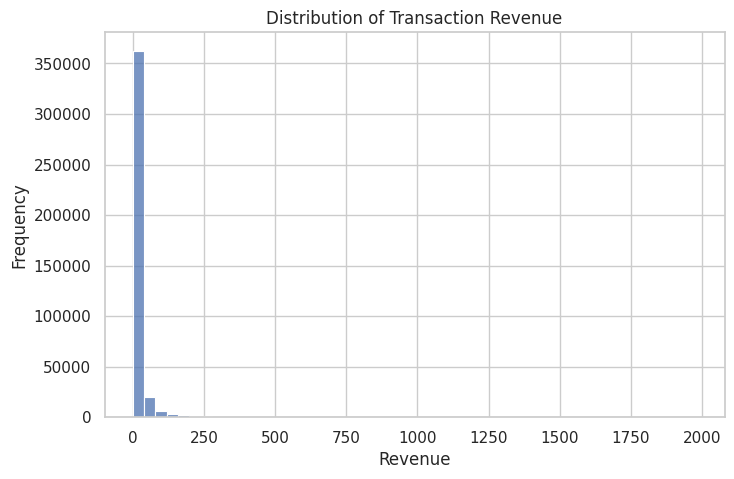

In [ ]:
# FILTERING EXTREME REVENUE OUTLIERS TO BETTER VISUALIZE THE DISTRIBUTION
revenue_filtered = df[df['Revenue'] < 2000]

plt.figure(figsize=(8,5))
sns.histplot(revenue_filtered['Revenue'], bins=50)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

---

### **REVENUE DISTRIBUTION – INSIGHTS**

---

**Key Observations:**

- Most transactions generate **low revenue values (largely below 100)**, while only a small number of transactions generate significantly higher revenue.
- This creates a **right-skewed distribution**, where the majority of observations are concentrated at lower revenue levels.
- The distribution indicates that the business experiences **many small purchases alongside relatively few high-value transactions**, which is typical in retail sales data.

---

# **8. MONTHLY REVENUE TREND ANALYSIS**

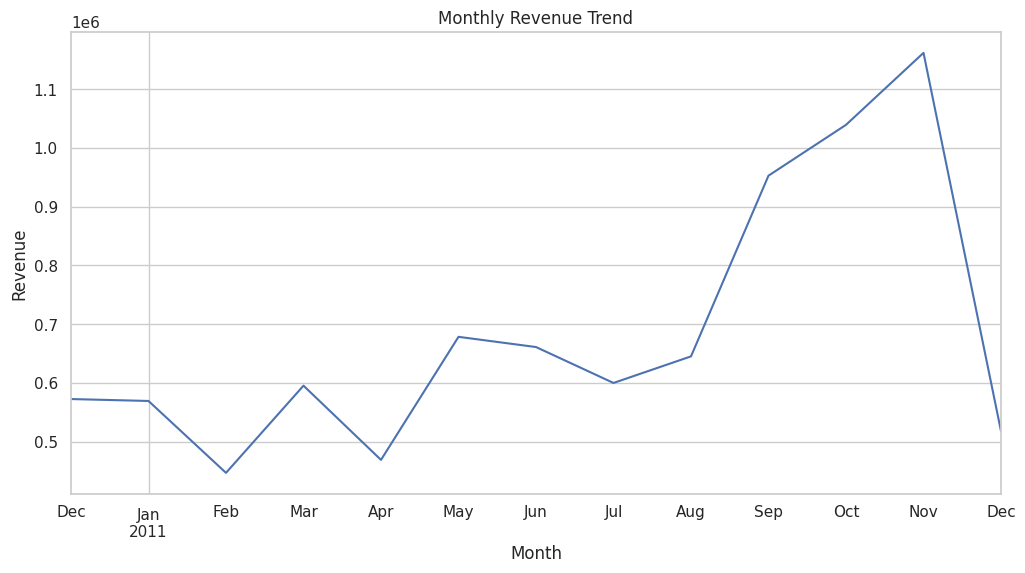

In [ ]:
# EXTRACTING MONTH
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

---

### **MONTHLY REVENUE TREND – INSIGHTS**

---

**Key Observations:**

- Monthly revenue fluctuates throughout the year, ranging approximately between **450,000 and 1,160,000**.
- Revenue begins to increase from **September onward**, indicating stronger sales in the later months of the year.
- The **highest revenue occurs in November**, suggesting peak seasonal demand during the holiday shopping period.
- The decline observed in **December** is likely due to **partial data availability**, as the dataset does not include the full month.

---

# **9. TOP REVENUE GENERATING PRODUCTS**

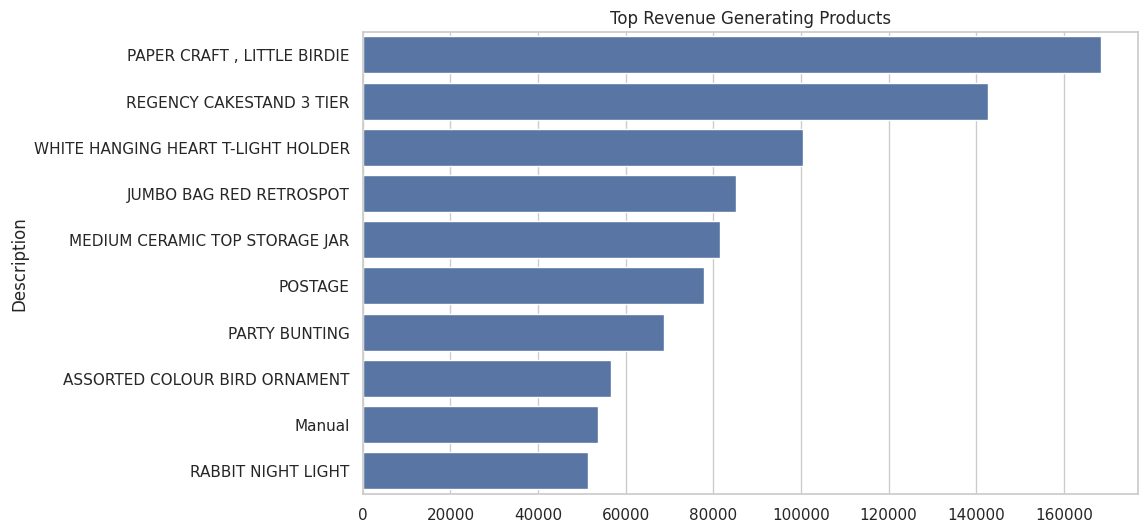

In [ ]:
# TOP PRODUCTS BY REVENUE
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top Revenue Generating Products")

plt.show()

---

### **TOP REVENUE GENERATING PRODUCTS – INSIGHTS**

---

**Key Observations:**

- **PAPER CRAFT , LITTLE BIRDIE** generates the highest revenue, exceeding **160,000**, making it the top-performing product.
- **REGENCY CAKESTAND 3 TIER** and **WHITE HANGING HEART T-LIGHT HOLDER** also contribute significantly to overall revenue.
- The top 10 products generate revenue ranging approximately from **50,000 to 168,000**.
- This indicates that a **small group of products plays a major role in driving total sales revenue**.

---

# **10. TOP PRODUCTS BY QUANTITY SOLD**

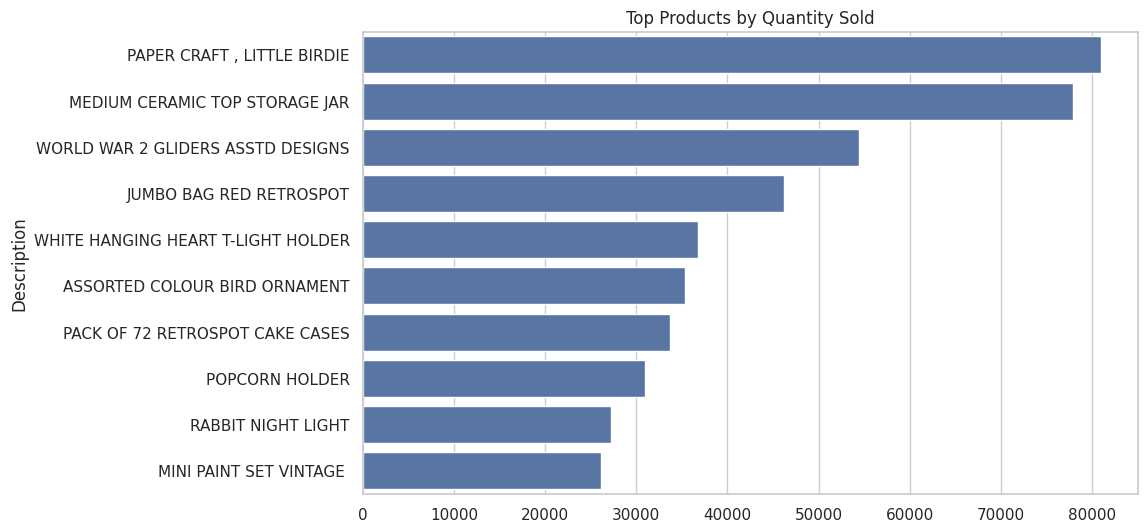

In [ ]:
# IDENTIFYING PRODUCTS SOLD IN HIGHEST QUANTITIES
top_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_quantity.values, y=top_quantity.index)

plt.title("Top Products by Quantity Sold")

plt.show()

---

### **TOP PRODUCTS BY QUANTITY SOLD – INSIGHTS**

---

**Key Observations:**

- **PAPER CRAFT , LITTLE BIRDIE** has the highest sales volume, exceeding **80,000 units sold**.
- **MEDIUM CERAMIC TOP STORAGE JAR** and **WORLD WAR 2 GLIDERS ASSTD DESIGNS** also show strong demand.
- The top products have sales volumes ranging approximately from **25,000 to 80,000 units**.
- This indicates that certain products experience **very high customer demand and frequent purchases**.

---

# **11. COUNTRY-WISE REVENUE ANALYSIS**

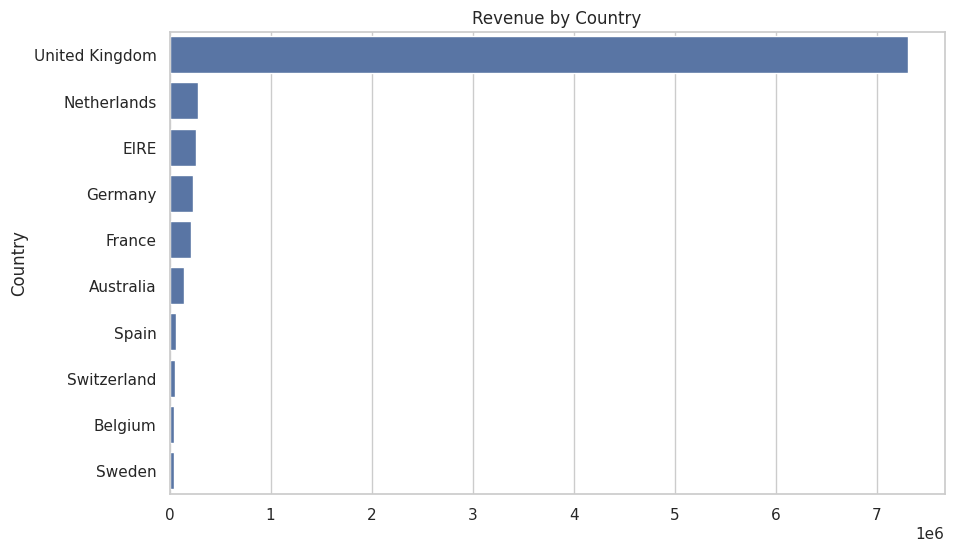

In [ ]:
# REVENUE BY COUNTRY
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=country_revenue.values, y=country_revenue.index)

plt.title("Revenue by Country")

plt.show()

---

### **COUNTRY-WISE REVENUE ANALYSIS – INSIGHTS**

---

**Key Observations:**

- The **United Kingdom generates the highest revenue**, exceeding **7 million**, making it the dominant market.
- Other countries such as **Netherlands, EIRE, Germany and France** contribute significantly smaller portions of revenue.
- The large gap between the UK and other countries indicates **strong geographic concentration of sales**.
- This suggests that the business is **highly dependent on the UK market**, with international markets contributing relatively smaller shares.

---

# **12. CUSTOMER CONTRIBUTION ANALYSIS**

In [ ]:
# CALCULATING TOTAL REVENUE GENERATED BY EACH CUSTOMER
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

customer_revenue

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


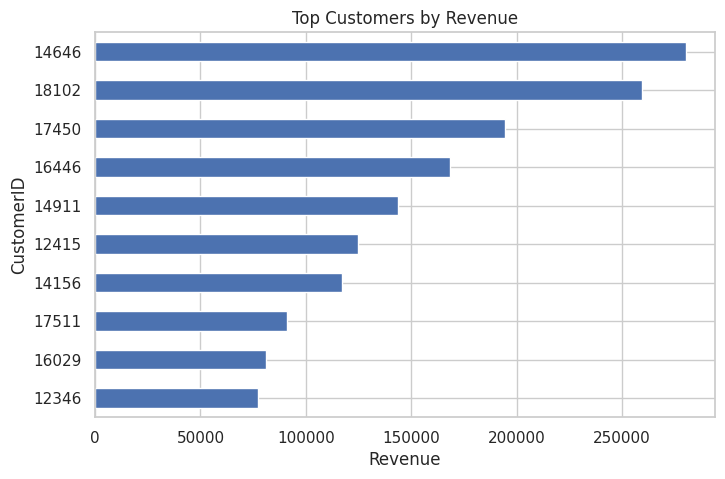

In [ ]:
# CONVERTING CUSTOMERID FROM FLOAT TO INTEGER FOR CLEANER LABELS
customer_revenue.index = customer_revenue.index.astype(int)

# PLOTTING TOP CUSTOMERS BY REVENUE
plt.figure(figsize=(8,5))

customer_revenue.plot(kind='barh')

plt.title("Top Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")

# INVERTING Y-AXIS SO HIGHEST VALUE APPEARS AT TOP
plt.gca().invert_yaxis()

plt.show()

---

### **CUSTOMER REVENUE CONTRIBUTION – INSIGHTS**

---

**Key Observations:**

- Customer **14646** generates the highest revenue, exceeding **270,000**.
- Customers **18102** and **17450** also contribute significantly to total sales.
- The top 10 customers generate revenue ranging approximately from **75,000 to 280,000**.
- This indicates that **a small group of high-value customers contributes a substantial share of total revenue**, highlighting the importance of customer retention strategies.

---

# **13. AVERAGE ORDER VALUE (AOV) ANALYSIS**

In [ ]:
# CALCULATING AVERAGE ORDER VALUES
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()

AOV = total_revenue / total_orders

print("Average Order Value:", round(AOV,2))

Average Order Value: 480.76


---

### **AVERAGE ORDER VALUE (AOV) – INSIGHTS**

---

**Key Observations:**

- The **Average Order Value (AOV)** is approximately **480.76**, meaning that each order generates around **480 in revenue on average**.
- A higher AOV suggests that customers often purchase **multiple items or higher-value products within a single transaction**.
- Businesses can increase AOV through strategies such as **product bundling, cross-selling, and targeted promotional offers**.

---

# **14. REVENUE CONCENTRATION (PARETO ANALYSIS)**

In [ ]:
# ANALYZING REVENUE CONCENTRATION
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

top_20_percent = product_revenue.head(int(len(product_revenue)*0.2))

print("Revenue from top 20% products:", round(top_20_percent.sum(),2))

Revenue from top 20% products: 7036402.86


---

### **REVENUE CONCENTRATION (PARETO ANALYSIS) – INSIGHTS**

---

**Key Observations:**

- The **top 20% of products generate approximately 7,036,402.86 in total revenue**, indicating strong revenue concentration.
- This shows that a **small proportion of products contributes a significant share of overall sales**.
- The pattern reflects the **Pareto Principle (80/20 rule)**, where a limited number of products drive a large portion of total revenue in retail businesses.

---

## **15. KEY BUSINESS INSIGHTS**

---

**Key Observations:**

- Revenue is **concentrated among a limited number of high-performing products**, indicating strong product-level revenue concentration.
- The **United Kingdom contributes the largest share of total revenue**, highlighting strong geographic dependence on a single market.
- Monthly revenue analysis reveals **seasonal fluctuations in sales**, with higher revenue observed toward the end of the year.
- A **small group of high-value customers generates a significant portion of total revenue**, emphasizing the importance of customer retention.
- Effective **product portfolio management and focus on high-performing items** can significantly support revenue optimization.

---

## **16. REVENUE OPTIMIZATION RECOMMENDATIONS**

---

**Strategic Recommendations:**

- Focus **marketing and promotional efforts on top revenue-generating products** identified in the analysis.
- Develop **loyalty programs and targeted offers** for high-value customers who contribute significantly to overall revenue.
- Increase **Average Order Value (AOV ≈ 480.76)** through product bundling, cross-selling, and targeted promotional campaigns.
- Expand **international sales markets** to reduce strong dependence on the United Kingdom market.
- Improve **inventory planning and stock management** by aligning supply with observed seasonal demand patterns.

---

## **17. CONCLUSION**

---

This project analysed a large e-commerce transactional dataset containing over **541,000 records** to identify key revenue drivers and business performance patterns.

The analysis revealed that revenue is **concentrated among a limited number of products and customers**, consistent with the **Pareto Principle (80/20 rule)**. The **United Kingdom contributes the majority of total revenue**, indicating strong geographic concentration.

Seasonal sales patterns were also identified, with revenue increasing toward the **later months of the year**, while the **Average Order Value (AOV) was approximately 480.76 per order**.

Overall, the analysis demonstrates how **data analytics can help businesses understand customer behaviour, identify revenue opportunities, and support data-driven decision-making in the e-commerce sector.**

---
---